#Libraries

In [ ]:
import numpy as np
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense, Conv2D,MaxPool2D,Dropout,Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
import glob
import matplotlib.pyplot as plt
import os
import cv2

#Read Data

In [ ]:
from IPython.display import clear_output
!pip install --upgrade kaggle
clear_output()
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

# Then move kaggle.json into the folder where the API expects to find it.
!mkdir -p ~/.kaggle/ && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json
User uploaded file "kaggle.json" with length 70 bytes


In [ ]:
!kaggle datasets download -d moltean/fruits

 99% 1.27G/1.28G [00:15<00:00, 90.9MB/s]
100% 1.28G/1.28G [00:15<00:00, 87.7MB/s]


In [ ]:
!unzip /content/fruits.zip -d input

Streaming output truncated to the last 5000 lines.
  inflating: input/fruits-360_dataset/fruits-360/Training/Tomato 3/111_100.jpg  
  inflating: input/fruits-360_dataset/fruits-360/Training/Tomato 3/112_100.jpg  
  inflating: input/fruits-360_dataset/fruits-360/Training/Tomato 3/113_100.jpg  
  inflating: input/fruits-360_dataset/fruits-360/Training/Tomato 3/114_100.jpg  
  inflating: input/fruits-360_dataset/fruits-360/Training/Tomato 3/115_100.jpg  
  inflating: input/fruits-360_dataset/fruits-360/Training/Tomato 3/116_100.jpg  
  inflating: input/fruits-360_dataset/fruits-360/Training/Tomato 3/117_100.jpg  
  inflating: input/fruits-360_dataset/fruits-360/Training/Tomato 3/119_100.jpg  
  inflating: input/fruits-360_dataset/fruits-360/Training/Tomato 3/120_100.jpg  
  inflating: input/fruits-360_dataset/fruits-360/Training/Tomato 3/121_100.jpg  
  inflating: input/fruits-360_dataset/fruits-360/Training/Tomato 3/122_100.jpg  
  inflating: input/fruits-360_dataset/fruits-360/Training/

In [ ]:
train_path ="input/fruits-360_dataset/fruits-360/Training"
test_path = "input/fruits-360_dataset/fruits-360/Test"
train_path

'input/fruits-360_dataset/fruits-360/Training'

#Plot Data

In [ ]:
className = glob.glob(train_path + "/*")
len(className)

131

In [ ]:
className[0]

'input/fruits-360_dataset/fruits-360/Training/Physalis with Husk'

In [ ]:
className[0].split('/')[-1]

'Physalis with Husk'

In [ ]:
className = glob.glob(train_path + "/*")
for i in range(len(glob.glob(train_path + "/*"))):
  className[i] = className[i].split('/')[-1]
className

['Physalis with Husk',
 'Pepper Orange',
 'Strawberry Wedge',
 'Pitahaya Red',
 'Tomato Yellow',
 'Nectarine',
 'Tomato Cherry Red',
 'Apple Red 2',
 'Corn',
 'Onion Red',
 'Apple Braeburn',
 'Guava',
 'Peach 2',
 'Apple Pink Lady',
 'Grape White 2',
 'Walnut',
 'Pomegranate',
 'Tomato Maroon',
 'Cherry Wax Red',
 'Cucumber Ripe',
 'Pear Kaiser',
 'Pear Stone',
 'Banana Red',
 'Apple Golden 3',
 'Orange',
 'Pear',
 'Apple Golden 1',
 'Nectarine Flat',
 'Grapefruit Pink',
 'Chestnut',
 'Potato Red Washed',
 'Pear Abate',
 'Rambutan',
 'Plum 3',
 'Pear Forelle',
 'Grape White 4',
 'Blueberry',
 'Physalis',
 'Mangostan',
 'Apricot',
 'Kaki',
 'Salak',
 'Fig',
 'Mango Red',
 'Cherry Wax Yellow',
 'Tomato 4',
 'Pear 2',
 'Apple Red 1',
 'Pepper Green',
 'Potato Sweet',
 'Nut Pecan',
 'Banana',
 'Peach',
 'Peach Flat',
 'Cocos',
 'Cherry Rainier',
 'Hazelnut',
 'Kiwi',
 'Tomato not Ripened',
 'Beetroot',
 'Grape Pink',
 'Kumquats',
 'Cantaloupe 2',
 'Apple Red Yellow 2',
 'Lemon',
 'Onion Wh

In [ ]:
len(className)
numberofclass = len(className)
print("numberofclass:" , numberofclass)

numberofclass: 131


In [ ]:
glob.glob('/content/input/fruits-360_dataset/fruits-360/Training/Apple Braeburn/'+"*")

In [ ]:
def plot(fruit):
  cl = glob.glob(train_path + '/'+fruit+'/'+'*')
  fig=plt.figure(figsize=(4,2))
  for i in range(1):
    ax=fig.add_subplot(1,1,i+1,xticks=[],yticks=[])
    plt.title(fruit)
    plt.axis("off")
    ax.imshow(load_img(train_path + '/'+fruit+'/'+cl[i].split('/')[-1]))

<ipython-input-19-a731ca160111>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig=plt.figure(figsize=(4,2))


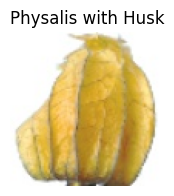

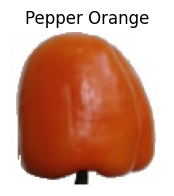

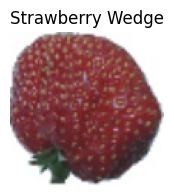

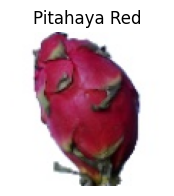

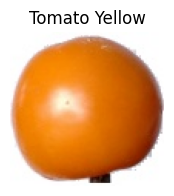

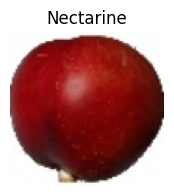

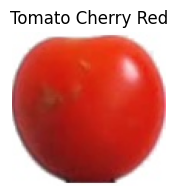

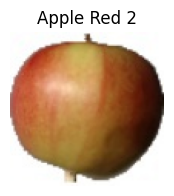

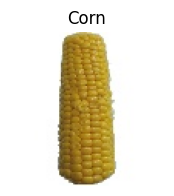

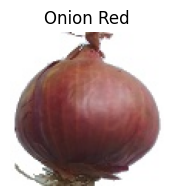

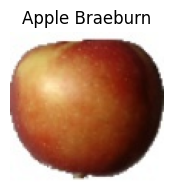

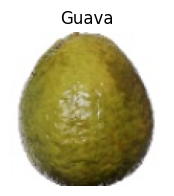

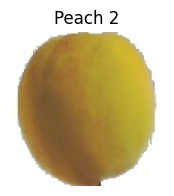

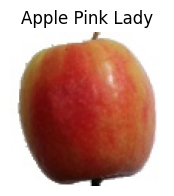

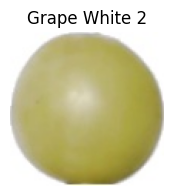

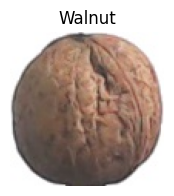

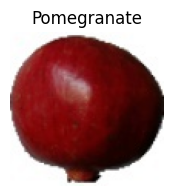

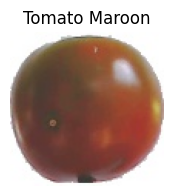

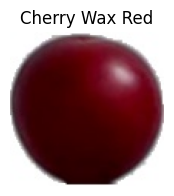

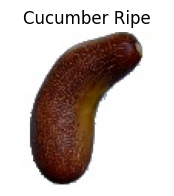

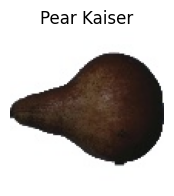

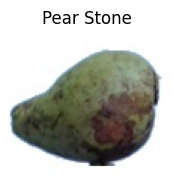

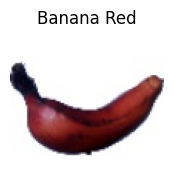

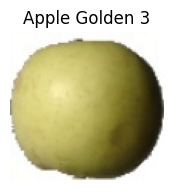

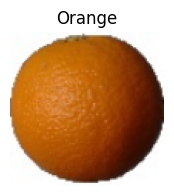

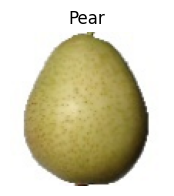

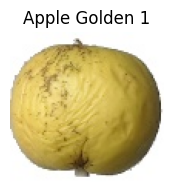

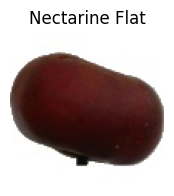

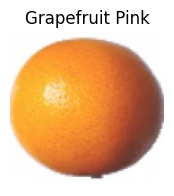

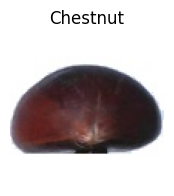

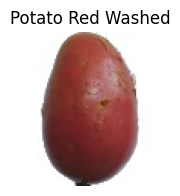

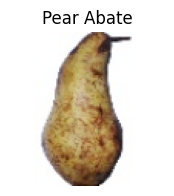

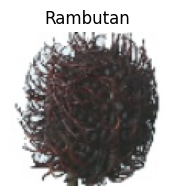

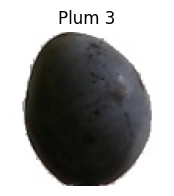

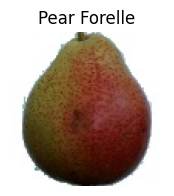

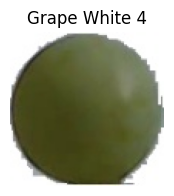

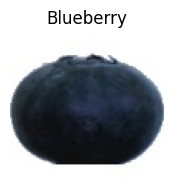

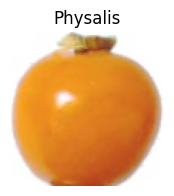

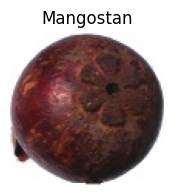

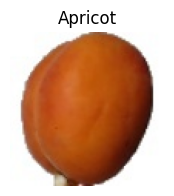

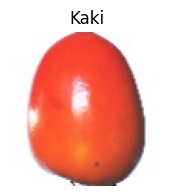

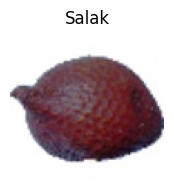

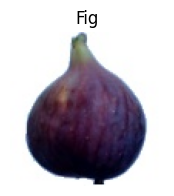

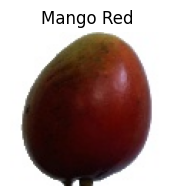

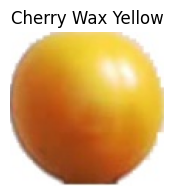

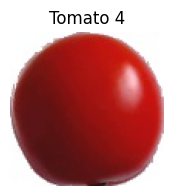

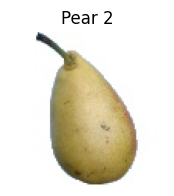

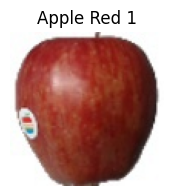

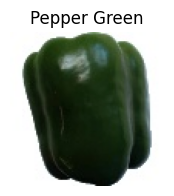

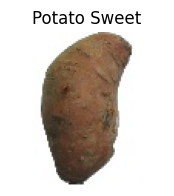

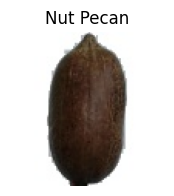

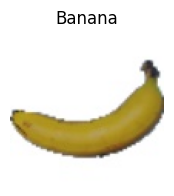

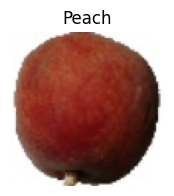

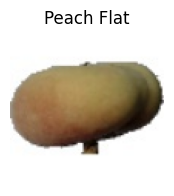

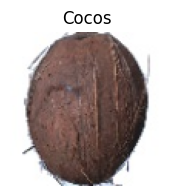

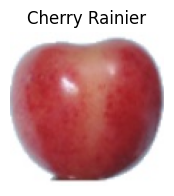

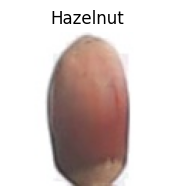

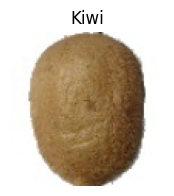

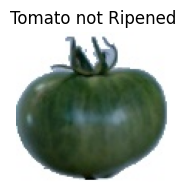

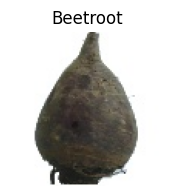

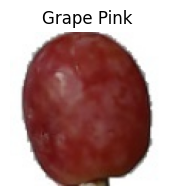

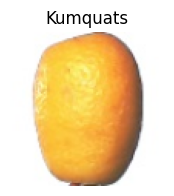

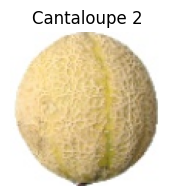

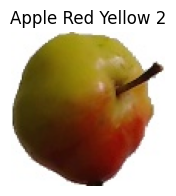

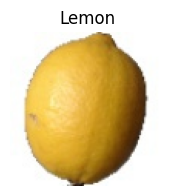

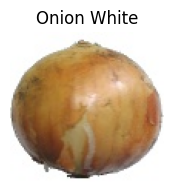

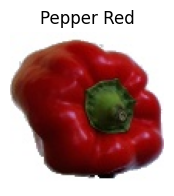

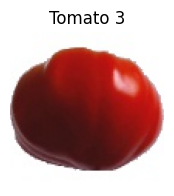

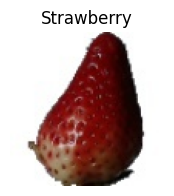

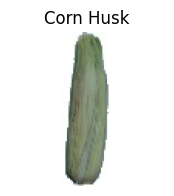

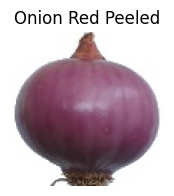

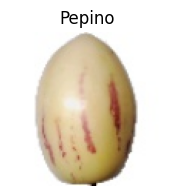

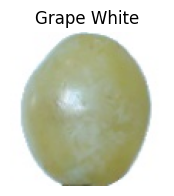

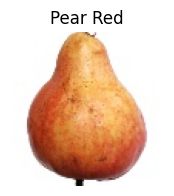

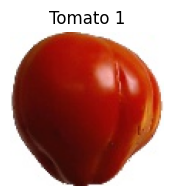

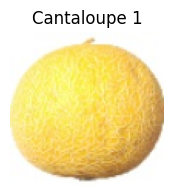

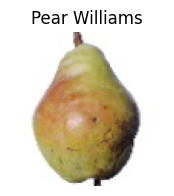

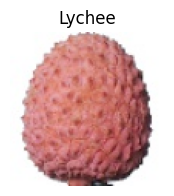

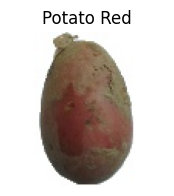

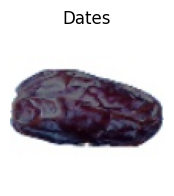

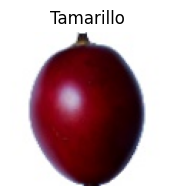

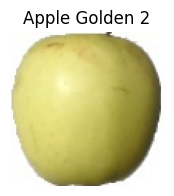

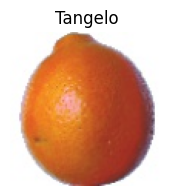

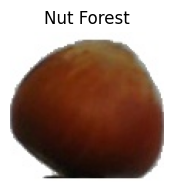

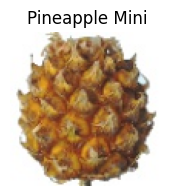

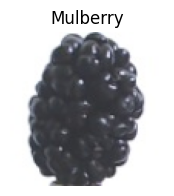

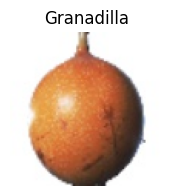

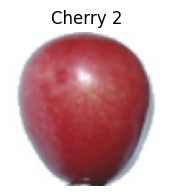

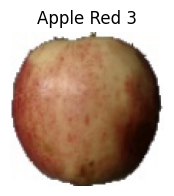

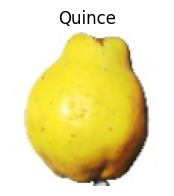

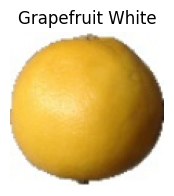

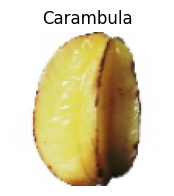

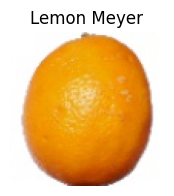

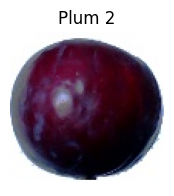

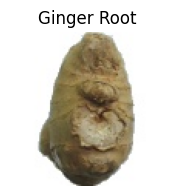

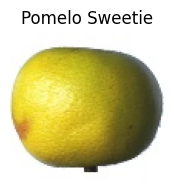

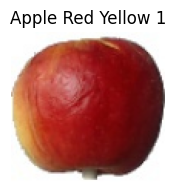

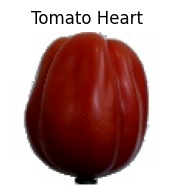

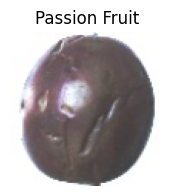

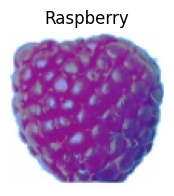

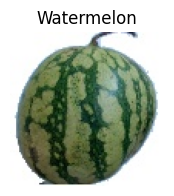

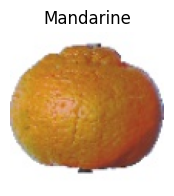

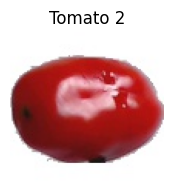

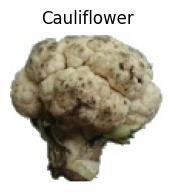

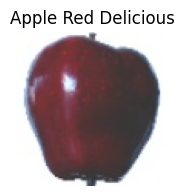

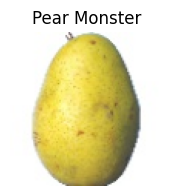

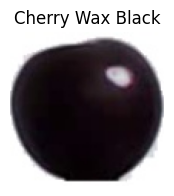

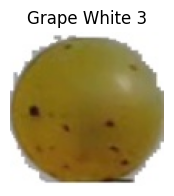

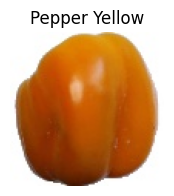

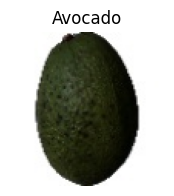

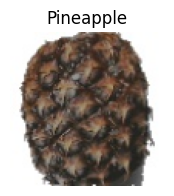

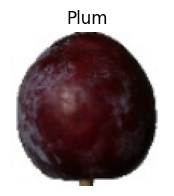

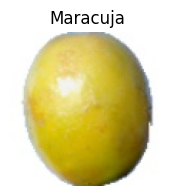

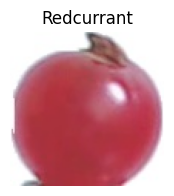

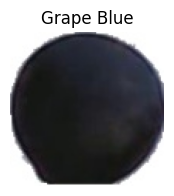

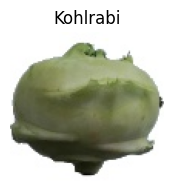

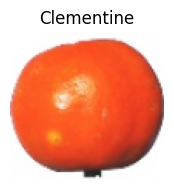

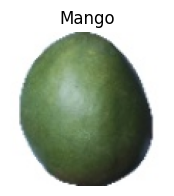

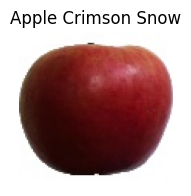

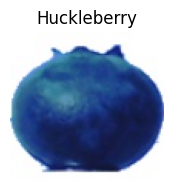

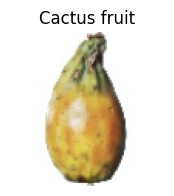

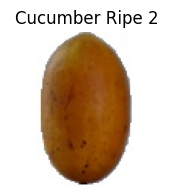

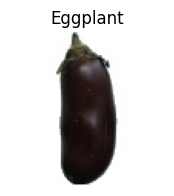

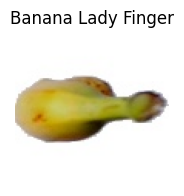

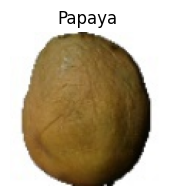

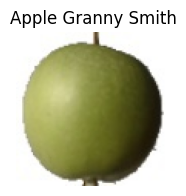

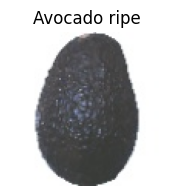

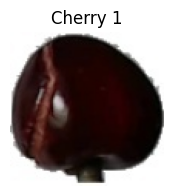

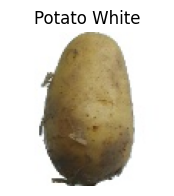

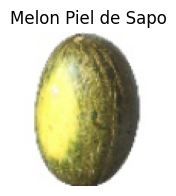

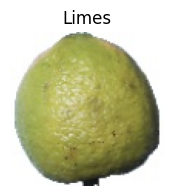

In [ ]:
for i in className:
  plot(i)

#Model

In [ ]:
model = Sequential()
model.add(Conv2D(32,kernel_size=(3,3),input_shape=(100,100,3),activation="relu"))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(32,kernel_size=(3,3),activation="relu"))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(64,kernel_size=(3,3),activation="relu"))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(1024, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(numberofclass,activation="softmax"))


model.compile(loss="categorical_crossentropy",optimizer="rmsprop",metrics=["accuracy"])
batch_size= 32

In [ ]:
train_data_generater = ImageDataGenerator(rescale=1./255,
                                          shear_range=0.3,
                                          horizontal_flip=True,
                                          zoom_range=0.3)

test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
x = np.zeros([100,100,3])

train_Generator = train_data_generater.flow_from_directory(train_path,target_size=x.shape[:2],
                                                           batch_size= batch_size,
                                                           color_mode="rgb",
                                                           class_mode="categorical")

test_Generator = test_datagen.flow_from_directory(test_path,
                                                  target_size=x.shape[:2],
                                                  batch_size=batch_size,
                                                  color_mode="rgb",
                                                  class_mode="categorical")

history = model.fit(train_Generator,
                    steps_per_epoch=1600 // batch_size,
                    epochs=15,
                    validation_data=test_Generator,
                    validation_steps=800 // batch_size)

Found 67692 images belonging to 131 classes.
Found 22688 images belonging to 131 classes.
Epoch 1/15
50/50 [==============================] - 18s 141ms/step - loss: 4.7349 - accuracy: 0.0206 - val_loss: 4.3632 - val_accuracy: 0.0450
Epoch 2/15
50/50 [==============================] - 9s 178ms/step - loss: 4.0304 - accuracy: 0.0712 - val_loss: 3.4092 - val_accuracy: 0.1150
Epoch 3/15
50/50 [==============================] - 5s 104ms/step - loss: 3.4489 - accuracy: 0.1481 - val_loss: 2.9319 - val_accuracy: 0.1975
Epoch 4/15
50/50 [==============================] - 7s 143ms/step - loss: 2.8809 - accuracy: 0.2325 - val_loss: 2.2458 - val_accuracy: 0.3700
Epoch 5/15
50/50 [==============================] - 6s 115ms/step - loss: 2.4092 - accuracy: 0.3300 - val_loss: 2.2053 - val_accuracy: 0.3837
Epoch 6/15
50/50 [==============================] - 7s 139ms/step - loss: 2.1673 - accuracy: 0.3794 - val_loss: 1.4697 - val_accuracy: 0.5838
Epoch 7/15
50/50 [==============================] - 6s 11

In [ ]:
train_Generator = train_data_generater.flow_from_directory(train_path,target_size=x.shape[:2],
                                                           batch_size= batch_size,
                                                           color_mode="rgb",
                                                           class_mode="categorical")

test_Generator = test_datagen.flow_from_directory(test_path,
                                                  target_size=x.shape[:2],
                                                  batch_size=batch_size,
                                                  color_mode="rgb",
                                                  class_mode="categorical")

history = model.fit(train_Generator,
                    steps_per_epoch=1600 // batch_size,
                    epochs=50,
                    validation_data=test_Generator,
                    validation_steps=800 // batch_size)

Found 67692 images belonging to 131 classes.
Found 22688 images belonging to 131 classes.
Epoch 1/50
50/50 [==============================] - 18s 127ms/step - loss: 4.7449 - accuracy: 0.0231 - val_loss: 4.3471 - val_accuracy: 0.0700
Epoch 2/50
50/50 [==============================] - 5s 108ms/step - loss: 4.0744 - accuracy: 0.0825 - val_loss: 3.4925 - val_accuracy: 0.1225
Epoch 3/50
50/50 [==============================] - 5s 110ms/step - loss: 3.4925 - accuracy: 0.1338 - val_loss: 2.9025 - val_accuracy: 0.2288
Epoch 4/50
50/50 [==============================] - 6s 127ms/step - loss: 2.9342 - accuracy: 0.1988 - val_loss: 2.4270 - val_accuracy: 0.3475
Epoch 5/50
50/50 [==============================] - 7s 138ms/step - loss: 2.5019 - accuracy: 0.3063 - val_loss: 2.0257 - val_accuracy: 0.4663
Epoch 6/50
50/50 [==============================] - 8s 157ms/step - loss: 2.1841 - accuracy: 0.3525 - val_loss: 1.7494 - val_accuracy: 0.5200
Epoch 7/50
50/50 [==============================] - 6s 11

In [ ]:
model.save_weights("fruit.h5")

#Evaluation

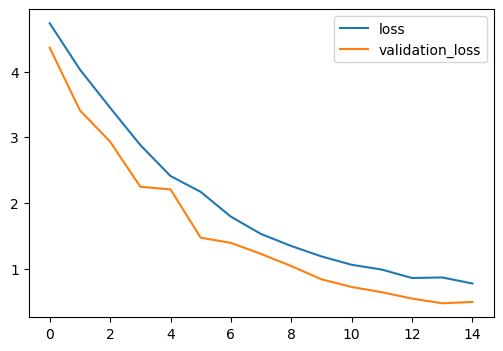

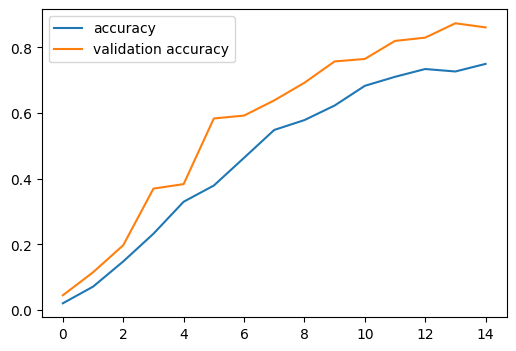

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"],label="loss")
plt.plot(history.history["val_loss"],label="validation_loss")
plt.legend()
plt.show()
plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"],label="accuracy")
plt.plot(history.history["val_accuracy"],label="validation accuracy")
plt.legend()
plt.show()

#Prediction

In [ ]:
new = np.expand_dims(image, axis=0)
new.shape

(1, 100, 100, 3)

In [ ]:
image = cv2.imread('/content/input/fruits-360_dataset/fruits-360/Test/Apple Braeburn/321_100.jpg')
image.shape
pred = model.predict(np.expand_dims(image, axis=0))

1/1 [==============================] - 0s 154ms/step


In [ ]:
numberofclass

131

In [ ]:
pred

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]], dtype=float32)

In [ ]:
className[np.argmax(pred,axis = 1)[0]]

'Redcurrant'

In [ ]:
def evaluate(path):
  image = cv2.imread(path)
  pred = model.predict(np.expand_dims(image, axis=0))

  fig=plt.figure(figsize=(4,2))
  for i in range(1):
    ax=fig.add_subplot(1,1,i+1,xticks=[],yticks=[])
    plt.title(className[np.argmax(pred,axis = 1)[0]])
    plt.axis("off")
    ax.imshow(load_img(path))

1/1 [==============================] - 0s 19ms/step


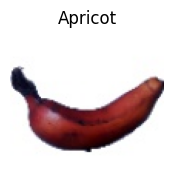

In [ ]:
evaluate('/content/input/fruits-360_dataset/fruits-360/Test/Banana Red/152_100.jpg')

1/1 [==============================] - 0s 20ms/step


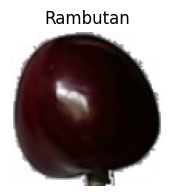

In [ ]:
evaluate('/content/input/fruits-360_dataset/fruits-360/Test/Cherry 1/321_100.jpg')

1/1 [==============================] - 0s 19ms/step


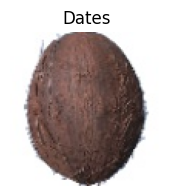

In [ ]:
evaluate('/content/input/fruits-360_dataset/fruits-360/Test/Cocos/0_100.jpg')